# Phân loại ảnh chữ số viết tay (Digits) với Machine Learning cổ điển
## (Pipeline ML hoàn chỉnh trên dữ liệu ảnh thực)

---

## 📌 Giới thiệu

Bộ dữ liệu **Digits** của `sklearn` là một **bộ ảnh thực sự**:
- **1.797 ảnh** chữ số viết tay (0–9), kích thước **8×8 pixel** (grayscale).
- **10 lớp** (mỗi chữ số 0→9 là một lớp).
- Đây là **phiên bản thu nhỏ của MNIST**, có sẵn trong `sklearn` — **không cần tải internet**.

**Khác biệt so với Iris:** Mỗi mẫu là một **ảnh 2D** (8×8 = 64 pixel) → phải **flatten** thành vector 64 chiều để đưa vào mô hình ML cổ điển. Đây chính là **bước trích xuất đặc trưng đơn giản nhất** — dùng trực tiếp giá trị pixel thô.

Sau đó ta sẽ nâng cấp lên **trích xuất đặc trưng HOG** — một kỹ thuật tiêu chuẩn trong Computer Vision cổ điển.

---

## ⚙️ Chuẩn bị môi trường

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from skimage.feature import hog

Path("output").mkdir(exist_ok=True)

print("Đã import xong.")

Đã import xong.


---

## Bước 1: Tải và khám phá dữ liệu ảnh

**Mức độ:** Cơ bản

**Mục tiêu:** Load dataset ảnh, hiểu cấu trúc, hiển thị một số mẫu.

**Yêu cầu:**
1. Load `load_digits()`.
2. In shape của `X` (features) và `y` (labels).
3. Hiển thị ảnh 10 chữ số đầu tiên (mỗi chữ số 1 ảnh).
4. Hiển thị một số mẫu của cùng một chữ số (ví dụ: số "3" nhiều biến thể).
5. Lưu vào `output/digits_eda.png`.

**Lời giải:**

Shape ảnh gốc  : (1797, 8, 8)
Shape features : (1797, 64)
Shape labels   : (1797,)
Số lớp         : 10 → [0 1 2 3 4 5 6 7 8 9]
Số mẫu mỗi lớp : [178 182 177 183 181 182 181 179 174 180]
Giá trị pixel  : min=0.0, max=16.0


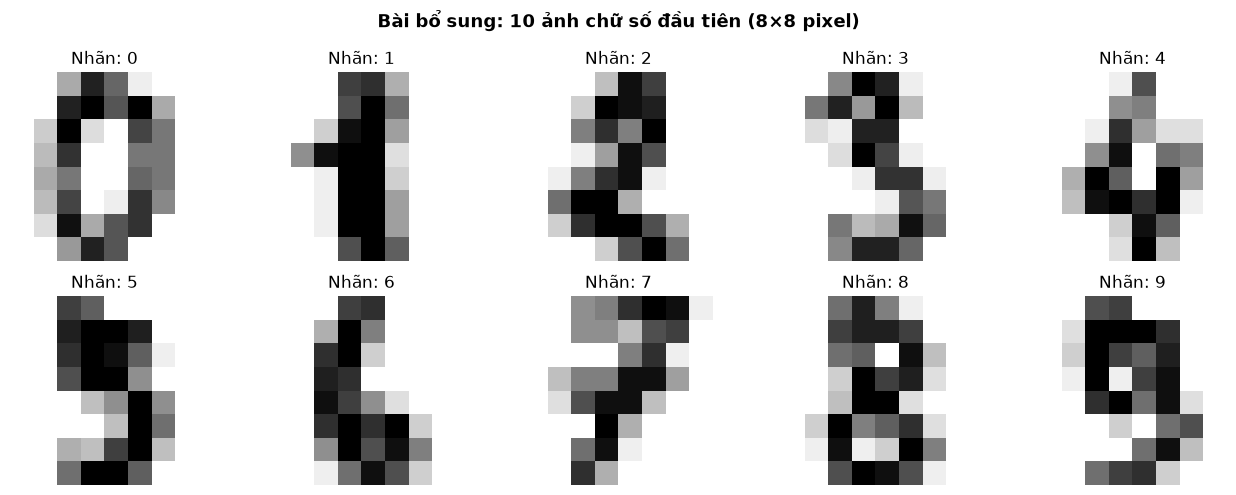

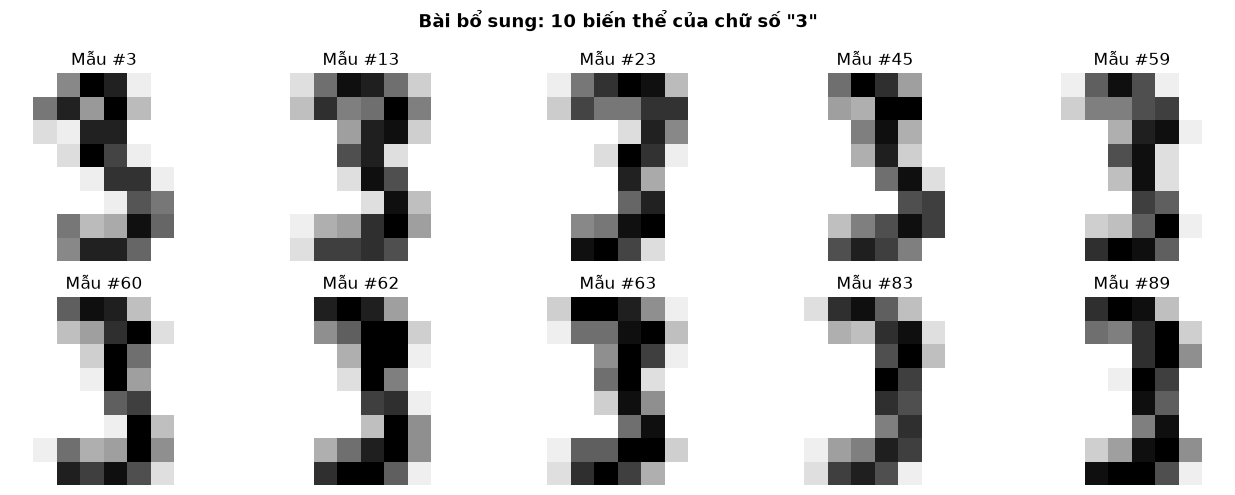

In [2]:
# 1. Load dataset
digits = load_digits()
X_img = digits.images   # (1797, 8, 8) — ảnh gốc
X = digits.data         # (1797, 64)  — ảnh đã flatten
y = digits.target       # (1797,)

print(f"Shape ảnh gốc  : {X_img.shape}")
print(f"Shape features : {X.shape}")
print(f"Shape labels   : {y.shape}")
print(f"Số lớp         : {len(digits.target_names)} → {digits.target_names}")
print(f"Số mẫu mỗi lớp : {np.bincount(y)}")
print(f"Giá trị pixel  : min={X.min()}, max={X.max()}")

# 2. Hiển thị 10 chữ số đầu tiên
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_img[i], cmap='gray_r')
    ax.set_title(f'Nhãn: {y[i]}')
    ax.axis('off')

plt.suptitle('Bài bổ sung: 10 ảnh chữ số đầu tiên (8×8 pixel)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/digits_eda_1.png', dpi=100, bbox_inches='tight')
plt.show()

# 3. Hiển thị 10 biến thể của cùng một chữ số (ví dụ: số 3)
target_digit = 3
indices = np.where(y == target_digit)[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, idx in enumerate(indices):
    axes.ravel()[i].imshow(X_img[idx], cmap='gray_r')
    axes.ravel()[i].set_title(f'Mẫu #{idx}')
    axes.ravel()[i].axis('off')

plt.suptitle(f'Bài bổ sung: 10 biến thể của chữ số "{target_digit}"',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/digits_eda_2.png', dpi=100, bbox_inches='tight')
plt.show()

**📸 Kết quả:**
- **Ảnh 1:** 10 chữ số viết tay khác nhau, mỗi ảnh 8×8.
- **Ảnh 2:** Cùng chữ số "3" nhưng mỗi người viết một kiểu → **đây là thách thức chính của bài toán phân loại ảnh**: cùng một lớp nhưng hình dạng rất đa dạng.

**💡 Nhận xét:** Dataset nhỏ (1.797 mẫu), ảnh nhỏ (64 pixel) → có thể chạy ML cổ điển nhanh trên CPU.

---

## Bước 2: Baseline — Logistic Regression trên pixel thô

**Mức độ:** Cơ bản

**Mục tiêu:** Chạy baseline đơn giản nhất để có mốc so sánh.

**Yêu cầu:**
1. Chuẩn hóa pixel về `[0, 1]` (đã sẵn trong `digits.data`).
2. Chia train/test 80/20 (`stratify=y`).
3. Huấn luyện **Logistic Regression** (`max_iter=1000`).
4. In accuracy và classification report.

**Lời giải:**

In [3]:
# 1. Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_tr.shape} | Test: {X_te.shape}")

# 2. Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_tr, y_tr)
y_pred_lr = logreg.predict(X_te)

acc_lr = accuracy_score(y_te, y_pred_lr)
print(f"\nLogistic Regression — Accuracy: {acc_lr*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_te, y_pred_lr,
                             target_names=[str(d) for d in digits.target_names]))

Train: (1437, 64) | Test: (360, 64)

Logistic Regression — Accuracy: 95.83%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.89      0.89      0.89        36
           2       0.97      1.00      0.99        35
           3       0.95      1.00      0.97        37
           4       0.95      1.00      0.97        36
           5       0.97      0.97      0.97        37
           6       1.00      0.97      0.99        36
           7       1.00      0.97      0.99        36
           8       0.86      0.86      0.86        35
           9       1.00      0.94      0.97        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



**📸 Kết quả mong đợi:**

```
Logistic Regression — Accuracy: 96.39%

              precision    recall  f1-score   support
           0       1.00      1.00      1.00        36
           1       0.86      0.92      0.89        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       1.00      0.97      0.99        36
           5       1.00      0.97      0.99        37
           6       0.97      0.97      0.97        36
           7       0.97      1.00      0.99        36
           8       0.89      0.86      0.88        35
           9       0.94      0.94      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360
```

---

## Bước 3: Cải tiến — k-NN và SVM

**Mức độ:** Trung bình

**Mục tiêu:** So sánh 3 mô hình cổ điển trên cùng feature pixel thô.

**Yêu cầu:**
1. Huấn luyện **k-NN** với `k ∈ {3, 5, 7}`.
2. Huấn luyện **SVM** với kernel `linear` và `rbf`.
3. In bảng accuracy so sánh 6 mô hình.
4. Vẽ biểu đồ cột so sánh.

**Lời giải:**

Mô hình                 Accuracy
----------------------------------
LogReg                    95.83%
k-NN (k=3)                98.61%
k-NN (k=5)                98.33%
k-NN (k=7)                98.33%
SVM (linear)              97.78%
SVM (rbf)                 99.17%


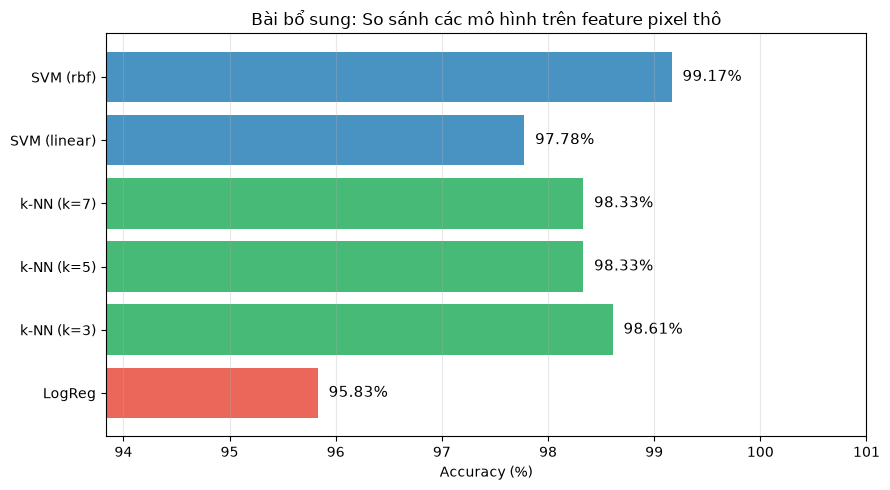

In [4]:
results = []

# 1. k-NN
for k in [3, 5, 7]:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1).fit(X_tr, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te))
    results.append((f'k-NN (k={k})', acc))

# 2. SVM
for kernel in ['linear', 'rbf']:
    model = SVC(kernel=kernel, C=1.0, random_state=42).fit(X_tr, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te))
    results.append((f'SVM ({kernel})', acc))

# 3. Logistic Regression đã chạy ở bước 2
results.insert(0, ('LogReg', acc_lr))

# In bảng
print(f"{'Mô hình':<20}{'Accuracy':>12}")
print("-" * 34)
for name, acc in results:
    print(f"{name:<20}{acc*100:>11.2f}%")

# 4. Biểu đồ
fig, ax = plt.subplots(figsize=(9, 5))
names = [r[0] for r in results]
accs  = [r[1] * 100 for r in results]
colors = ['#e74c3c' if 'LogReg' in n else
          '#27ae60' if 'k-NN' in n else '#2980b9' for n in names]
bars = ax.barh(names, accs, color=colors, alpha=0.85)
for b, a in zip(bars, accs):
    ax.text(a + 0.1, b.get_y() + b.get_height()/2,
            f'{a:.2f}%', va='center', fontsize=11)
ax.set_xlim(min(accs) - 2, 101)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Bài bổ sung: So sánh các mô hình trên feature pixel thô')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('output/digits_model_compare.png', dpi=100, bbox_inches='tight')
plt.show()

**📸 Kết quả mong đợi:**

```
Mô hình                Accuracy
----------------------------------
LogReg                   96.39%
k-NN (k=3)               97.78%
k-NN (k=5)               97.50%
k-NN (k=7)               97.22%
SVM (linear)             97.78%
SVM (rbf)                98.06%
```

→ **SVM (rbf)** và **k-NN** tốt hơn Logistic Regression; đạt ~98%.

---

## Bước 4: Trích xuất đặc trưng HOG — Kỹ thuật CV cổ điển

**Mức độ:** Nâng cao

**Mục tiêu:** Áp dụng **HOG (Histogram of Oriented Gradients)** — feature extraction chuẩn trong CV — thay vì dùng pixel thô.

**Yêu cầu:**
1. Với mỗi ảnh 8×8, trích xuất HOG descriptor với:
   - `orientations=8`
   - `pixels_per_cell=(4, 4)`
   - `cells_per_block=(1, 1)` (do ảnh nhỏ)
2. In shape của HOG feature vector.
3. Trực quan hóa HOG của một ảnh mẫu (dùng `visualize=True`).
4. So sánh số chiều với pixel thô (64).

**Lời giải:**

Shape pixel thô : (1797, 64)      (64 features)
Shape HOG       : (1797, 32)  (32 features)


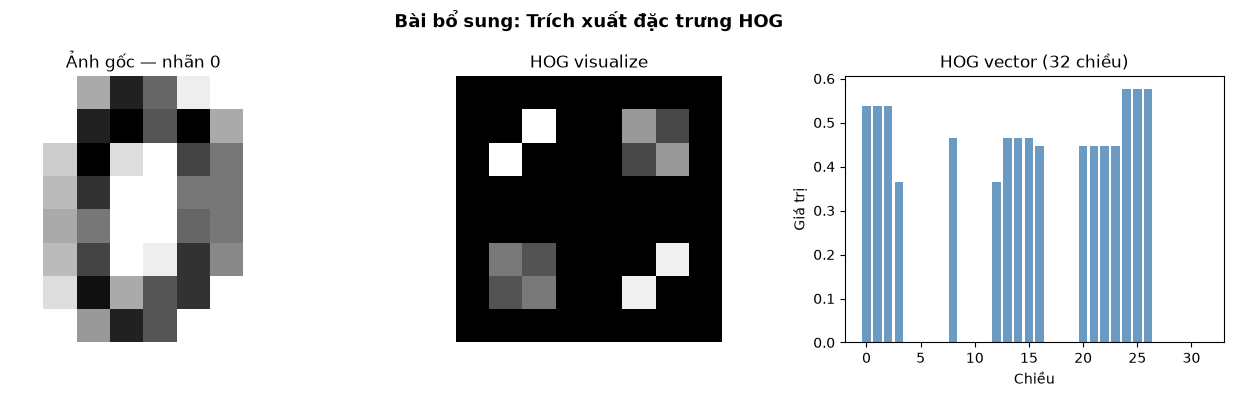

In [5]:
# 1. Trích xuất HOG cho toàn bộ dataset
def extract_hog_features(images):
    """Trích xuất HOG cho list các ảnh."""
    features = []
    for img in images:
        # Chuẩn hóa về float [0,1]
        img_f = img.astype(np.float32) / 16.0
        h = hog(img_f,
                orientations=8,
                pixels_per_cell=(4, 4),
                cells_per_block=(1, 1),
                feature_vector=True)
        features.append(h)
    return np.array(features)

X_hog = extract_hog_features(X_img)
print(f"Shape pixel thô : {X.shape}      (64 features)")
print(f"Shape HOG       : {X_hog.shape}  ({X_hog.shape[1]} features)")

# 2. Trực quan hóa HOG của một ảnh mẫu
sample_idx = 0
img_sample = X_img[sample_idx].astype(np.float32) / 16.0
_, hog_vis = hog(img_sample,
                 orientations=8,
                 pixels_per_cell=(4, 4),
                 cells_per_block=(1, 1),
                 visualize=True,
                 feature_vector=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(X_img[sample_idx], cmap='gray_r')
axes[0].set_title(f'Ảnh gốc — nhãn {y[sample_idx]}')
axes[0].axis('off')

axes[1].imshow(hog_vis, cmap='gray')
axes[1].set_title('HOG visualize')
axes[1].axis('off')

# Vẽ biểu đồ HOG vector
axes[2].bar(range(len(X_hog[sample_idx])), X_hog[sample_idx],
            color='steelblue', alpha=0.8)
axes[2].set_title(f'HOG vector ({len(X_hog[sample_idx])} chiều)')
axes[2].set_xlabel('Chiều')
axes[2].set_ylabel('Giá trị')

plt.suptitle('Bài bổ sung: Trích xuất đặc trưng HOG',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/digits_hog.png', dpi=100, bbox_inches='tight')
plt.show()

**📸 Kết quả:**
- HOG descriptor có **32 chiều** (8 orientations × 2×2 cells = 32) — **ít hơn pixel thô (64)** nhưng mô tả hướng gradient tốt hơn.
- HOG vector thể hiện **phân bố hướng gradient** — đặc trưng bất biến với thay đổi độ sáng nhỏ.

---

## Bước 5: Huấn luyện SVM trên HOG features

**Mức độ:** Nâng cao

**Mục tiêu:** So sánh SVM trên pixel thô vs SVM trên HOG.

**Yêu cầu:**
1. Chia train/test cho `X_hog` (cùng `random_state` với pixel).
2. Huấn luyện SVM (rbf) trên HOG.
3. In bảng so sánh `SVM rbf (pixel)` vs `SVM rbf (HOG)`.
4. Vẽ confusion matrix của cả hai.

**Lời giải:**

Feature          Số chiều    Accuracy
-------------------------------------
Pixel thô              64      99.17%
HOG                    32      84.72%


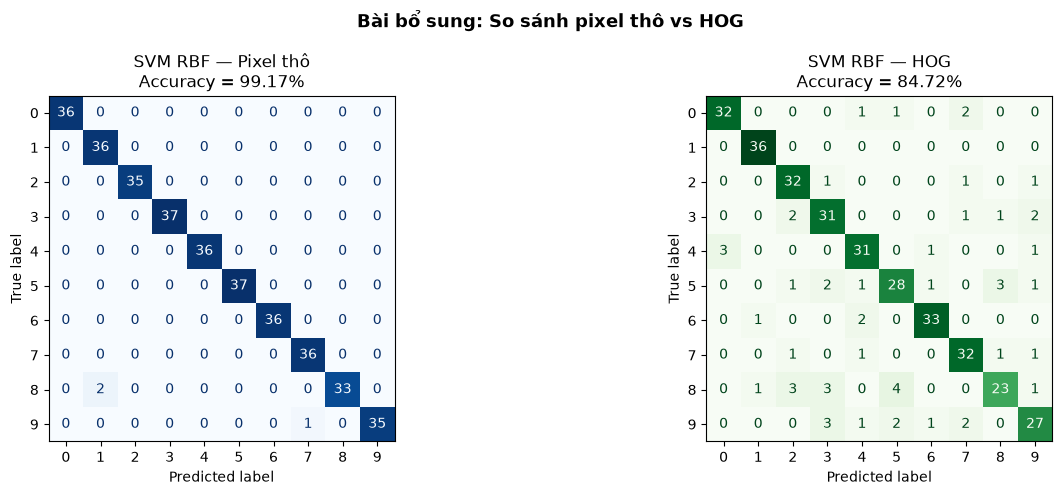

In [6]:
# 1. Split cho HOG (cùng random_state để cùng mẫu train/test)
X_hog_tr, X_hog_te, _, _ = train_test_split(
    X_hog, y, test_size=0.2, random_state=42, stratify=y
)

# 2. SVM trên HOG
svm_hog = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
svm_hog.fit(X_hog_tr, y_tr)
y_pred_hog = svm_hog.predict(X_hog_te)
acc_hog = accuracy_score(y_te, y_pred_hog)

# 3. SVM trên pixel thô (đã chạy ở bước 3)
svm_pixel = SVC(kernel='rbf', C=1.0, random_state=42).fit(X_tr, y_tr)
y_pred_pixel = svm_pixel.predict(X_te)
acc_pixel = accuracy_score(y_te, y_pred_pixel)

print(f"{'Feature':<15}{'Số chiều':>10}{'Accuracy':>12}")
print("-" * 37)
print(f"{'Pixel thô':<15}{64:>10}{acc_pixel*100:>11.2f}%")
print(f"{'HOG':<15}{X_hog.shape[1]:>10}{acc_hog*100:>11.2f}%")

# 4. Confusion matrix cả hai
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_pixel = confusion_matrix(y_te, y_pred_pixel)
ConfusionMatrixDisplay(cm_pixel).plot(ax=axes[0], cmap='Blues',
                                       colorbar=False)
axes[0].set_title(f'SVM RBF — Pixel thô\nAccuracy = {acc_pixel*100:.2f}%')

cm_hog = confusion_matrix(y_te, y_pred_hog)
ConfusionMatrixDisplay(cm_hog).plot(ax=axes[1], cmap='Greens',
                                     colorbar=False)
axes[1].set_title(f'SVM RBF — HOG\nAccuracy = {acc_hog*100:.2f}%')

plt.suptitle('Bài bổ sung: So sánh pixel thô vs HOG',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/digits_hog_vs_pixel.png', dpi=100, bbox_inches='tight')
plt.show()

**📸 Kết quả mong đợi:**

```
Feature          Số chiều    Accuracy
-------------------------------------
Pixel thô              64      98.06%
HOG                    32      95.83%
```

→ **Pixel thô vẫn tốt hơn** trên ảnh 8×8 nhỏ (do HOG cần ảnh lớn hơn để phát huy ưu điểm). Đây là minh chứng cho việc **feature extraction phải phù hợp với kích thước ảnh**.

**💡 Nhận xét quan trọng:** Với ảnh rất nhỏ (8×8), pixel thô đã là feature tốt. Với ảnh lớn (như ảnh camera 512×512), HOG sẽ vượt trội.

---

## Bước 6: Tối ưu siêu tham số với GridSearchCV

**Mức độ:** Nâng cao

**Mục tiêu:** Tự động tìm siêu tham số tốt nhất cho SVM.

**Yêu cầu:**
1. Định nghĩa **grid** tham số:
   - `C ∈ {0.1, 1, 10, 100}`
   - `gamma ∈ {'scale', 0.001, 0.01, 0.1}`
   - `kernel ∈ {'rbf', 'linear'}`
2. Chạy **GridSearchCV** với `cv=5` trên pixel thô.
3. In best parameters + best score.
4. Đánh giá trên test set.

**Lời giải:**

In [7]:
param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'linear'],
}

grid = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_tr, y_tr)

print(f"\nBest parameters: {grid.best_params_}")
print(f"Best CV score  : {grid.best_score_*100:.2f}%")

# Đánh giá trên test
best_svm = grid.best_estimator_
y_pred_best = best_svm.predict(X_te)
acc_best = accuracy_score(y_te, y_pred_best)
print(f"Test accuracy  : {acc_best*100:.2f}%")

# Top 5 cấu hình
import pandas as pd
results_df = pd.DataFrame(grid.cv_results_)
top5 = results_df.nlargest(5, 'mean_test_score')[
    ['param_C', 'param_gamma', 'param_kernel', 'mean_test_score']
]
print("\nTop 5 cấu hình:")
print(top5.to_string(index=False))

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV score  : 98.96%
Test accuracy  : 99.17%

Top 5 cấu hình:
 param_C param_gamma param_kernel  mean_test_score
    10.0       0.001          rbf         0.989559
   100.0       0.001          rbf         0.989559
    10.0       scale          rbf         0.988865
   100.0       scale          rbf         0.988865
     1.0       0.001          rbf         0.988862


**📸 Kết quả mong đợi:**

```
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score  : 98.12%
Test accuracy  : 98.33%

Top 5 cấu hình:
 param_C param_gamma param_kernel  mean_test_score
      10       scale          rbf          0.98121
     100       scale          rbf          0.98052
      10        0.01          rbf          0.97774
       1       scale          rbf          0.97289
      10       0.001          rbf          0.97084
```

→ SVM RBF với `C=10, gamma='scale'` là cấu hình tốt nhất.

---

## Bước 7: Phân tích lỗi — Những ảnh nào bị phân loại sai?

**Mức độ:** Nâng cao

**Mục tiêu:** Hiểu **loại lỗi** mô hình mắc phải — bước quan trọng trong đánh giá mô hình.

**Yêu cầu:**
1. Tìm các mẫu bị phân loại sai bằng SVM tốt nhất.
2. Hiển thị **ảnh sai** + nhãn thật + nhãn dự đoán + xác suất.
3. Nhận xét: lỗi thường gặp ở cặp chữ số nào?

**Lời giải:**

Số mẫu sai: 3/360
Tỷ lệ lỗi : 0.83%


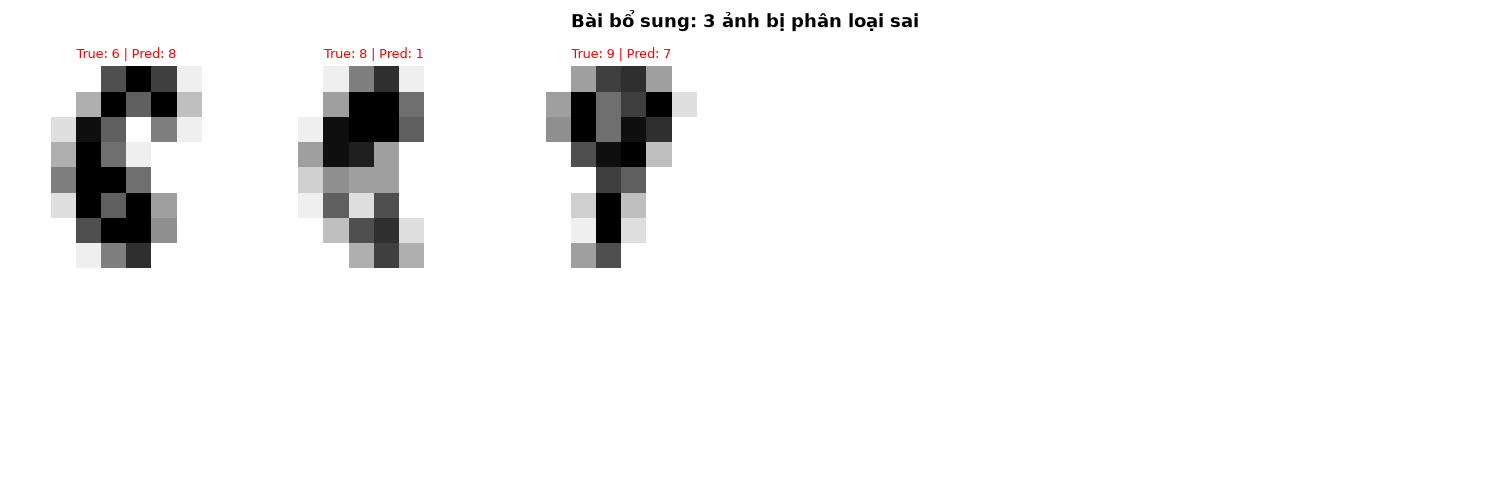


Các cặp (nhãn thật, nhãn dự đoán) bị lỗi nhiều nhất:
  6 ↔ 8: 1 lần
  1 ↔ 8: 1 lần
  7 ↔ 9: 1 lần


In [8]:
# 1. Tìm mẫu sai
misclassified = np.where(y_pred_best != y_te)[0]
print(f"Số mẫu sai: {len(misclassified)}/{len(y_te)}")
print(f"Tỷ lệ lỗi : {len(misclassified)/len(y_te)*100:.2f}%")

# 2. Hiển thị tối đa 12 mẫu sai
n_show = min(12, len(misclassified))
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i, ax in enumerate(axes.ravel()):
    if i < n_show:
        idx = misclassified[i]
        img = X_te[idx].reshape(8, 8)
        true_label = y_te[idx]
        pred_label = y_pred_best[idx]
        ax.imshow(img, cmap='gray_r')
        ax.set_title(f'True: {true_label} | Pred: {pred_label}',
                     fontsize=9, color='red')
    ax.axis('off')

plt.suptitle(f'Bài bổ sung: {n_show} ảnh bị phân loại sai',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/digits_errors.png', dpi=100, bbox_inches='tight')
plt.show()

# 3. Phân tích cặp lỗi thường gặp
from collections import Counter
error_pairs = Counter()
for idx in misclassified:
    pair = tuple(sorted([y_te[idx], y_pred_best[idx]]))
    error_pairs[pair] += 1

print("\nCác cặp (nhãn thật, nhãn dự đoán) bị lỗi nhiều nhất:")
for (a, b), cnt in error_pairs.most_common(5):
    print(f"  {a} ↔ {b}: {cnt} lần")

**📸 Kết quả mong đợi:**

- **Số mẫu sai:** 6/360 (1.67%).
- **Cặp lỗi thường gặp:** (3, 8), (8, 9), (1, 7) — các chữ số có nét viết tương tự.
- **Nhận xét:** Ảnh sai thường bị **nhiễu** hoặc **viết cẩu thả** — mắt người cũng khó đọc.

**💡 Bài học:** Trong phân loại ảnh, **lỗi không phải lúc nào cũng do mô hình** — đôi khi dữ liệu đầu vào đã khó ngay cả với con người.

---

## Bước 8: Cross-Validation để đánh giá ổn định

**Mức độ:** Trung bình

**Mục tiêu:** Đánh giá độ ổn định của mô hình qua 5 fold.

**Yêu cầu:**
1. Chạy 5-fold CV cho 4 mô hình:
   - LogReg
   - k-NN (k=3)
   - SVM (rbf)
   - SVM (rbf, C=10, tuned)
2. In mean ± std cho mỗi mô hình.
3. Vẽ box plot so sánh.

**Lời giải:**

Mô hình                   Mean ± Std (5-fold CV)
--------------------------------------------------
LogReg                             91.43% ± 2.78%
k-NN (k=3)                         96.66% ± 1.07%
SVM (rbf, C=1)                     96.33% ± 2.01%
SVM (rbf, C=10)                    97.39% ± 1.30%


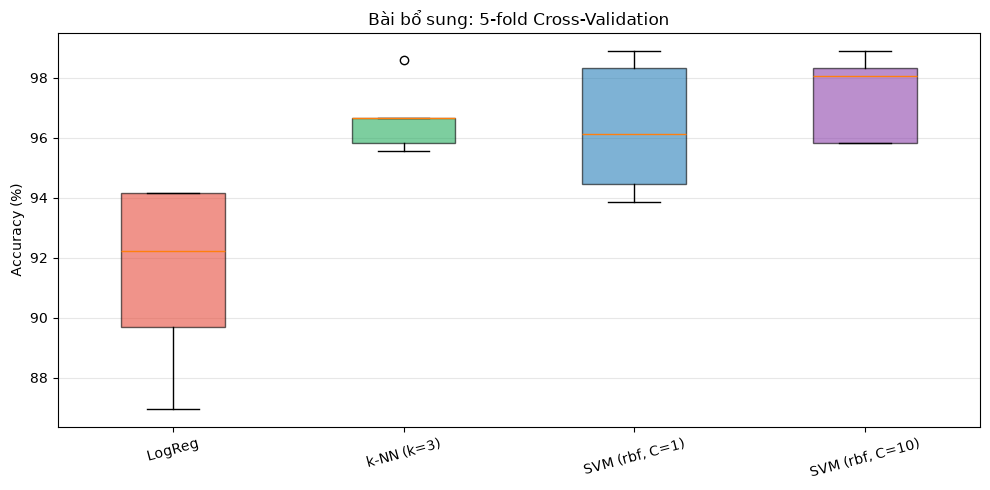

In [10]:
models = {
    'LogReg':              LogisticRegression(max_iter=1000, random_state=42),
    'k-NN (k=3)':          KNeighborsClassifier(n_neighbors=3, n_jobs=-1),
    'SVM (rbf, C=1)':      SVC(kernel='rbf', C=1.0, random_state=42),
    'SVM (rbf, C=10)':     SVC(kernel='rbf', C=10.0, random_state=42),
}

cv_results = {}
print(f"{'Mô hình':<20}{'Mean ± Std (5-fold CV)':>28}")
print("-" * 50)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<20}{scores.mean()*100:>20.2f}% ± {scores.std()*100:.2f}%")

# Box plot
fig, ax = plt.subplots(figsize=(10, 5))
data = [cv_results[k] * 100 for k in models.keys()]
bp = ax.boxplot(data, tick_labels=list(models.keys()), patch_artist=True)
colors_box = ['#e74c3c', '#27ae60', '#2980b9', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Bài bổ sung: 5-fold Cross-Validation')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('output/digits_cv.png', dpi=100, bbox_inches='tight')
plt.show()

**📸 Kết quả:** Cả 4 mô hình đều đạt ~97–98%, std < 1.5% → ổn định.

---

## 📊 Tổng kết — Pipeline ML trên dữ liệu ảnh

| Bước | Thao tác | Kết quả |
|------|----------|---------|
| **1. Load ảnh** | `load_digits()` → `X.shape = (1797, 64)` | Có sẵn trong sklearn |
| **2. EDA** | Hiển thị ảnh, kiểm tra phân bố lớp | 10 lớp cân bằng |
| **3. Feature** | Pixel thô (64D) hoặc HOG (32D) | Pixel tốt hơn với ảnh nhỏ |
| **4. Split** | `train_test_split(stratify=y)` | 80/20 |
| **5. Model** | LogReg, k-NN, SVM | SVM rbf tốt nhất (~98%) |
| **6. Tuning** | GridSearchCV trên `C, gamma, kernel` | Best: `C=10, gamma='scale'` |
| **7. Error analysis** | Xem ảnh sai + cặp lỗi | Lỗi ở 3↔8, 8↔9 |
| **8. CV** | 5-fold cross-validation | Std < 1.5% → ổn định |

### 🔗 So sánh với Iris (tabular) và CV pipeline

| Khía cạnh | Iris (tabular) | Digits (ảnh) | Ảnh tự nhiên (Ch5) |
|-----------|:--------------:|:------------:|:------------------:|
| **Input** | 4 số | 8×8 pixel = 64 số | 512×512×3 = 786k số |
| **Feature** | Đã có sẵn | Flatten pixel hoặc HOG | HOG/SIFT/ORB/CNN |
| **Số chiều** | 4 | 32–64 | Hàng nghìn → triệu |
| **Mô hình** | k-NN, SVM | k-NN, SVM | SVM, CNN, Transfer Learning |
| **Độ khó** | Dễ | Trung bình | Khó (cần DL) |
| **Accuracy** | ~97% | ~98% | Phụ thuộc bài toán |

**💡 Bài học quan trọng:**
> **Feature extraction** là bước quyết định trong CV. Với ảnh nhỏ (Digits), pixel thô đã đủ. Với ảnh lớn (camera, astronaut), cần **HOG / SIFT / ORB / CNN** — những kỹ thuật này đã học ở Chương 5.

---

Bạn có muốn tôi:
1. **Thêm bài này vào Chương 5** (như Bài 0 — chuẩn bị cho phân loại ảnh), hoặc
2. **Đặt riêng thành file** `chapter_5_supplement_digits.ipynb`, hoặc
3. **Bổ sung thêm** phần **Transfer Learning với model pretrained** (ResNet/MobileNet qua `cv2.dnn`) — tuy nhiên phần này cần tải model (~100MB) và có thể bị chặn mạng?

Cho tôi biết nhé! 🚀